# Population-Level Burstiness: Hierarchical PSD Recovery

Individual galaxies weakly constrain the PSD timescale τ_PS. A population
sharing the same burstiness physics can break this degeneracy. No other
SED-fitting code can do this.

**The hierarchical model**: shared hyperparameters ϕ = (σ_PS, τ_PS) govern
the burstiness prior for every galaxy. Per-galaxy latent variables include
the GP field ξ_i (128 dims) and physical parameters θ_i (7 dims). Total
dimensionality: D = N × (128 + 7) + 2 shared.

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    PopulationFitter,
    Model,
    Observation,
    Parameters,
    Photometry,
    Spectroscopy,
    Uniform,
    load_ssp_data,
)

import sys, os  # noqa: E401

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("demonstrations", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import (
    COLORS,
    convergence_table,
    plot_corner_comparison,
    plot_sfh,
    safe_corner,
    setup_style,
)

setup_style()

In [2]:
# Load SSP data and define observation
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)
obs = Observation(
    photometry=Photometry.from_names(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"]),
    spectroscopy=Spectroscopy(wave_obs=WAVE_OBS),
)

# True shared PSD parameters
TRUE_SIGMA = 2.0
TRUE_TAU = 20.0
N_GAL = 10
SPEC_SNR = 30.0
PHOT_SNR = 20.0

In [3]:
# Model factory for hierarchical inference
def model_factory(psd_sigma=1.0, psd_tau_myr=50.0):
    """Create a Model with fixed PSD — called by PopulationFitter."""
    spec = Parameters(
        sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
        sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
        sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
        sfh_tsnorm_skew=Uniform(-3.0, 3.0),
        sfh_tsnorm_trunc=Uniform(1.0, 10.0),
        sfh_field_psd_sigma=Fixed(psd_sigma),
        sfh_field_psd_tau_myr=Fixed(psd_tau_myr),
        met_logzsol=Uniform(-2.0, 0.2),
        dust_tau_bc=Uniform(0.0, 2.0),
        dust_tau_diff=Uniform(0.0, 1.5),
        dust_slope=Fixed(-0.7),
        redshift=Fixed(0.1),
        mean_sfh_type=["tsnorm", "field"],
        n_grid=128,
    )
    return Model(spec, ssp_data, observation=obs)

In [4]:
# Generate N mock galaxies with shared PSD
print(f"Generating {N_GAL} mock galaxies with σ_PS = {TRUE_SIGMA}, τ_PS = {TRUE_TAU} Myr...")
key = jax.random.PRNGKey(42)
model_gen = model_factory(psd_sigma=TRUE_SIGMA, psd_tau_myr=TRUE_TAU)

galaxies_spec = []  # spectroscopic data
galaxies_phot = []  # photometric data
true_params_all = []

for i in range(N_GAL):
    k = jax.random.fold_in(key, i)
    params = model_gen.spec.sample(k)

    # Spectroscopic mock
    mock_s = model_gen.mock_spectrum(params, WAVE_OBS, snr=SPEC_SNR, key=jax.random.fold_in(k, 1))
    galaxies_spec.append({"flux_obs": mock_s.flux_obs, "noise": mock_s.noise})

    # Photometric mock
    mock_p = model_gen.mock(params, snr=PHOT_SNR, key=jax.random.fold_in(k, 2))
    galaxies_phot.append({"flux_obs": mock_p.flux_obs, "noise": mock_p.noise})

    true_params_all.append(params)

print(f"  Spectroscopy: {len(WAVE_OBS)} pixels, SNR = {SPEC_SNR}")
print(f"  Photometry: {obs.n_data_phot} bands, SNR = {PHOT_SNR}")

Generating 10 mock galaxies with σ_PS = 2.0, τ_PS = 20.0 Myr...


W0325 22:55:34.066315 21002547 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_77598/4226601108.py:20: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  return Model(spec, ssp_data, observation=obs)
<local>/Projects/diffsed/src/tengri/core/model.py:466: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  self.precompute_spectroscopy(observation.spectroscopy.wave_obs)


  Spectroscopy: 200 pixels, SNR = 30.0
  Photometry: 5 bands, SNR = 20.0


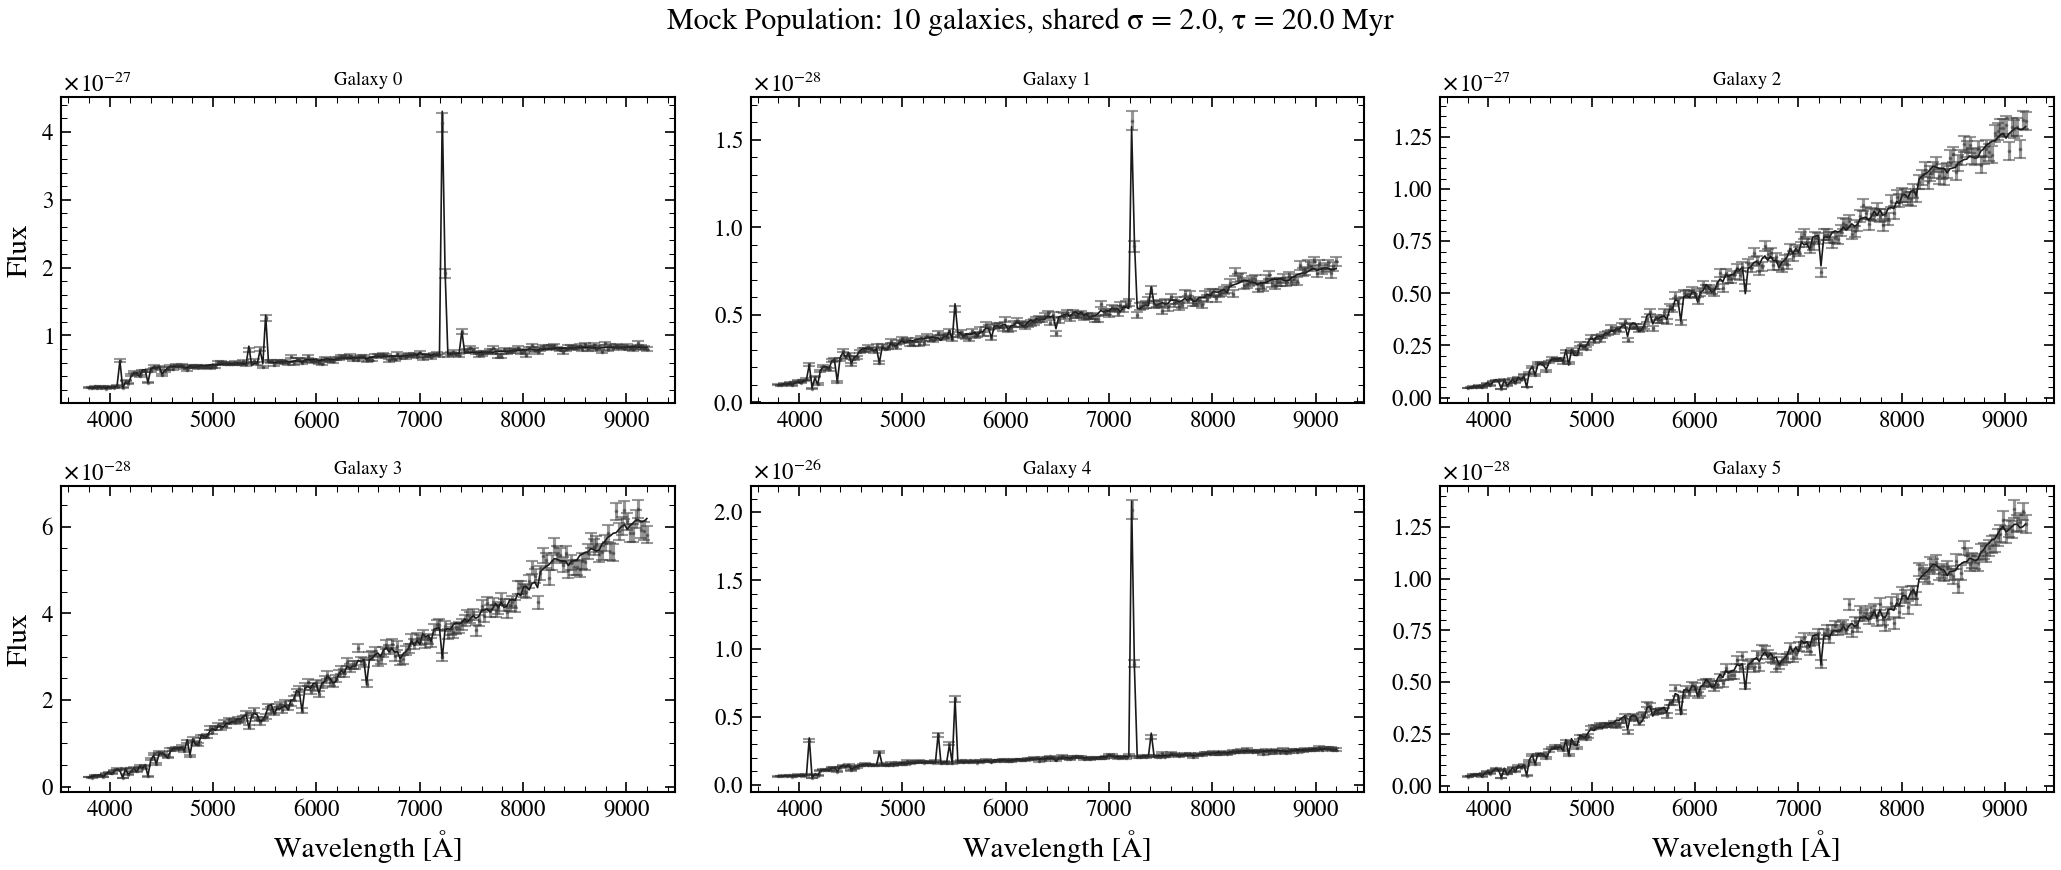

In [5]:
# --- FIGURE 1: Galaxy diversity ---
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    if i >= min(6, N_GAL):
        ax.set_visible(False)
        continue
    ax.errorbar(
        np.array(WAVE_OBS),
        np.array(galaxies_spec[i]["flux_obs"]),
        yerr=np.array(galaxies_spec[i]["noise"]),
        fmt=".",
        ms=1.5,
        color=COLORS["data"],
        alpha=0.5,
    )
    true_spec = model_gen.predict_spectrum(true_params_all[i])
    ax.plot(np.array(WAVE_OBS), np.array(true_spec), color=COLORS["truth"], lw=0.8)
    ax.set_title(f"Galaxy {i}", fontsize=9)
    if i >= 3:
        ax.set_xlabel("Wavelength [Å]")
    if i % 3 == 0:
        ax.set_ylabel("Flux")
fig.suptitle(f"Mock Population: {N_GAL} galaxies, shared σ = {TRUE_SIGMA}, τ = {TRUE_TAU} Myr")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig01_galaxy_diversity.png"), dpi=150, bbox_inches="tight")
plt.show()

## Individual Fits: Weak Constraints

When we fit each galaxy individually (with PSD parameters free), σ_PS is
roughly constrained but τ_PS is nearly unconstrained — it spans the prior.

In [6]:
# Individual native_geovi fits with FREE PSD
spec_free = Parameters(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    sfh_field_psd_sigma=Uniform(0.1, 4.0),
    sfh_field_psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type=["tsnorm", "field"],
    n_grid=128,
)
model_free = Model(spec_free, ssp_data, observation=obs)

individual_results = []
print("Fitting individual galaxies (PSD free)...")
for i in range(min(4, N_GAL)):
    fitter_i = Fitter(
        model_free,
        galaxies_spec[i]["flux_obs"],
        galaxies_spec[i]["noise"],
        data_type="spectroscopy",
    )
    t0_c = time.perf_counter()
    fitter_i.compile(verbose=False)
    t_compile = time.perf_counter() - t0_c
    t0 = time.perf_counter()
    res_i = fitter_i.run(
        "vi",
        n_iterations=15,
        n_samples=6,
        n_seeds=3,
        n_posterior_samples=500,
        verbose=False,
    )
    t_run = time.perf_counter() - t0
    individual_results.append(res_i)
    sig_med = float(jnp.median(res_i.samples["sfh_field_psd_sigma"]))
    tau_med = float(jnp.median(res_i.samples["sfh_field_psd_tau_myr"]))
    print(f"  Galaxy {i}: σ = {sig_med:.2f}, τ = {tau_med:.0f} Myr")
    print(f"    XLA compile: {t_compile:.1f}s (one-time, cached)")
    print(f"    native_geovi: {t_run:.1f}s <- runtime per galaxy")

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_77598/3857459254.py:18: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_free = Model(spec_free, ssp_data, observation=obs)


Fitting individual galaxies (PSD free)...


assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


<local>/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


...

W0325 23:01:14.519577 21002355 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0325 23:01:16.630559 21002355 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0325 23:02:45.345563 21002355 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0325 23:02:56.278657 21002355 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  Galaxy 3: σ = 1.90, τ = 182 Myr
    XLA compile: 73.7s (one-time, cached)
    native_geovi: 32.1s <- runtime per galaxy


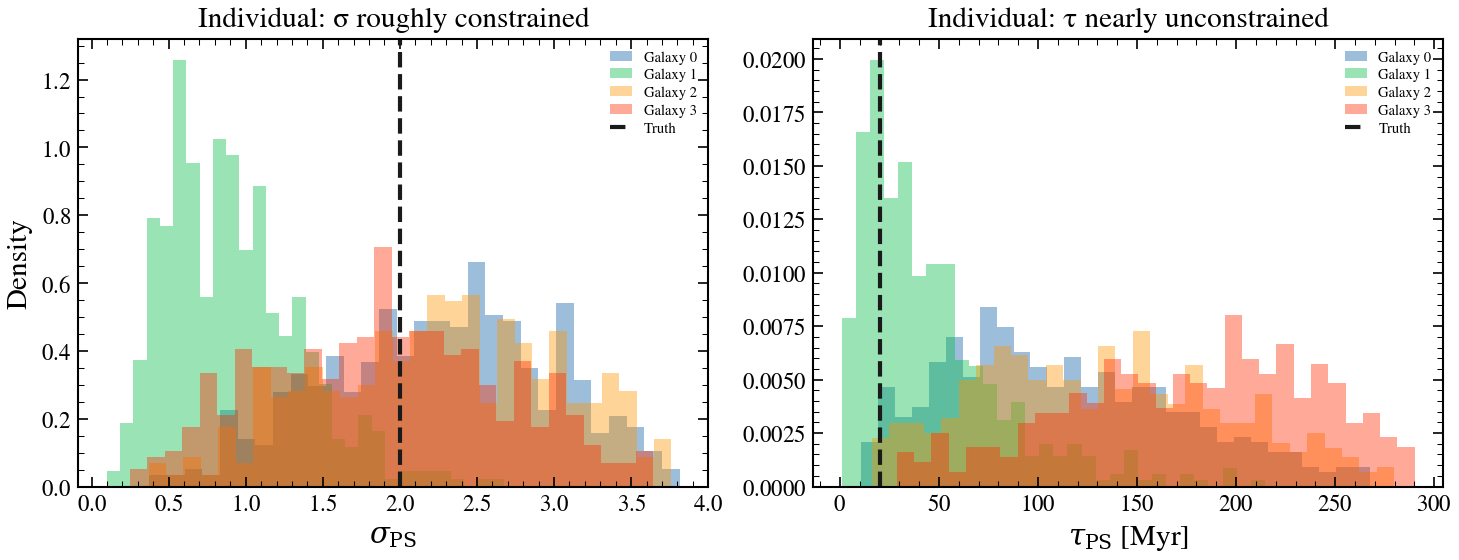

In [7]:
# --- FIGURE 2: Individual PSD posteriors (wide, overlapping) ---
fig, (ax_sig, ax_tau) = plt.subplots(1, 2, figsize=(10, 4))
for i, res in enumerate(individual_results):
    sig_s = np.array(res.samples["sfh_field_psd_sigma"])
    tau_s = np.array(res.samples["sfh_field_psd_tau_myr"])
    ax_sig.hist(sig_s, bins=30, alpha=0.4, density=True, label=f"Galaxy {i}")
    ax_tau.hist(tau_s, bins=30, alpha=0.4, density=True, label=f"Galaxy {i}")

ax_sig.axvline(TRUE_SIGMA, color=COLORS["truth"], lw=2, ls="--", label="Truth")
ax_tau.axvline(TRUE_TAU, color=COLORS["truth"], lw=2, ls="--", label="Truth")
ax_sig.set_xlabel(r"$\sigma_{\rm PS}$")
ax_tau.set_xlabel(r"$\tau_{\rm PS}$ [Myr]")
ax_sig.set_ylabel("Density")
ax_sig.legend(fontsize=7)
ax_tau.legend(fontsize=7)
ax_sig.set_title("Individual: σ roughly constrained")
ax_tau.set_title("Individual: τ nearly unconstrained")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig02_individual_psd.png"), dpi=150, bbox_inches="tight")
plt.show()

## Hierarchical Inference

The hierarchical model shares σ_PS and τ_PS across all N galaxies while
allowing each galaxy its own physical parameters and GP field. This pools
information about the burstiness timescale, dramatically tightening τ_PS.

In [8]:
# Hierarchical native_geovi on SPECTROSCOPIC data
print(f"\nHierarchical fit: {N_GAL} galaxies (spectroscopy)...")
t0 = time.perf_counter()
hfitter_spec = PopulationFitter(
    model_factory,
    galaxies_spec,
    psd_sigma_prior=(0.1, 4.0),
    psd_tau_prior=(1.0, 300.0),
    data_type="spectroscopy",
)
result_hier_spec = hfitter_spec.run(
    "evi",
    n_iterations=50,
    n_samples=6,
    n_posterior_samples=500,
    n_seeds=10,
    verbose=False,
    key=jax.random.PRNGKey(0),
)
t_hier_spec = time.perf_counter() - t0

sig_spec = np.array(result_hier_spec.shared_samples["psd_sigma"])
tau_spec = np.array(result_hier_spec.shared_samples["psd_tau_myr"])
print(
    f"  σ_PS = {np.median(sig_spec):.2f} [{np.percentile(sig_spec, 16):.2f}, {np.percentile(sig_spec, 84):.2f}]"
)
print(
    f"  τ_PS = {np.median(tau_spec):.0f} [{np.percentile(tau_spec, 16):.0f}, {np.percentile(tau_spec, 84):.0f}] Myr"
)
print(f"  Wall time: {t_hier_spec:.1f}s")


Hierarchical fit: 10 galaxies (spectroscopy)...


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_77598/4226601108.py:20: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  return Model(spec, ssp_data, observation=obs)
<local>/Projects/diffsed/src/tengri/core/model.py:466: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  self.precompute_spectroscopy(observation.spectroscopy.wave_obs)


W0325 23:03:05.942646 21002355 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0325 23:06:34.264914 21002355 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  σ_PS = 0.10 [0.10, 0.11]
  τ_PS = 298 [294, 299] Myr
  Wall time: 230.8s


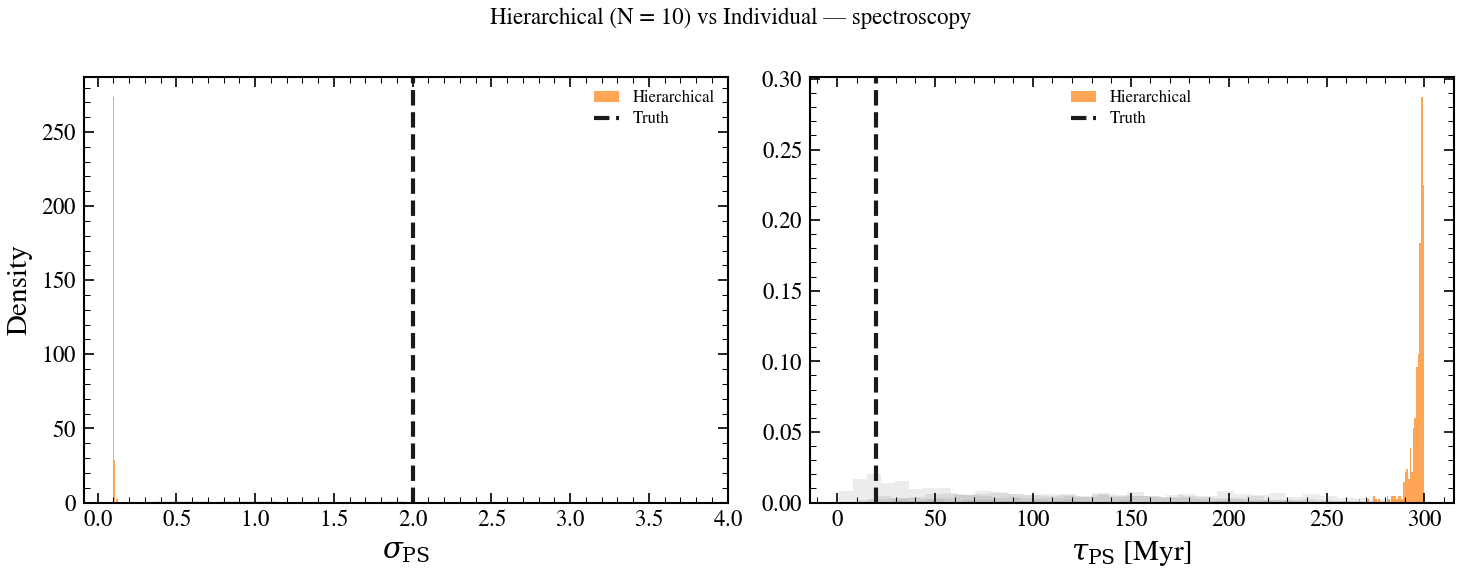

In [9]:
# --- FIGURE 3: Hierarchical vs individual PSD ---
fig, (ax_sig, ax_tau) = plt.subplots(1, 2, figsize=(10, 4))

# Individual (faded)
for i, res in enumerate(individual_results):
    sig_s = np.array(res.samples["sfh_field_psd_sigma"])
    tau_s = np.array(res.samples["sfh_field_psd_tau_myr"])
    ax_sig.hist(sig_s, bins=30, alpha=0.15, density=True, color="grey")
    ax_tau.hist(tau_s, bins=30, alpha=0.15, density=True, color="grey")

# Hierarchical (bold)
ax_sig.hist(
    sig_spec, bins=40, alpha=0.7, density=True, color=COLORS["geovi"], label="Hierarchical"
)
ax_tau.hist(
    tau_spec, bins=40, alpha=0.7, density=True, color=COLORS["geovi"], label="Hierarchical"
)

ax_sig.axvline(TRUE_SIGMA, color=COLORS["truth"], lw=2, ls="--", label="Truth")
ax_tau.axvline(TRUE_TAU, color=COLORS["truth"], lw=2, ls="--", label="Truth")
ax_sig.set_xlabel(r"$\sigma_{\rm PS}$")
ax_tau.set_xlabel(r"$\tau_{\rm PS}$ [Myr]")
ax_sig.set_ylabel("Density")
ax_sig.legend(fontsize=8)
ax_tau.legend(fontsize=8)
fig.suptitle(f"Hierarchical (N = {N_GAL}) vs Individual — spectroscopy", fontsize=11)
fig.tight_layout()
plt.savefig(
    os.path.join(FIGDIR, "fig03_hierarchical_vs_individual.png"), dpi=150, bbox_inches="tight"
)
plt.show()

## Spectroscopy vs Photometry for Population PSD

In [10]:
# Hierarchical native_geovi on PHOTOMETRIC data
print(f"\nHierarchical fit: {N_GAL} galaxies (photometry)...")
t0 = time.perf_counter()
hfitter_phot = PopulationFitter(
    model_factory,
    galaxies_phot,
    psd_sigma_prior=(0.1, 4.0),
    psd_tau_prior=(1.0, 300.0),
    data_type="photometry",
)
result_hier_phot = hfitter_phot.run(
    "evi",
    n_iterations=50,
    n_samples=6,
    n_posterior_samples=500,
    n_seeds=10,
    verbose=False,
    key=jax.random.PRNGKey(1),
)
t_hier_phot = time.perf_counter() - t0

sig_phot = np.array(result_hier_phot.shared_samples["psd_sigma"])
tau_phot = np.array(result_hier_phot.shared_samples["psd_tau_myr"])
print(
    f"  σ_PS = {np.median(sig_phot):.2f} [{np.percentile(sig_phot, 16):.2f}, {np.percentile(sig_phot, 84):.2f}]"
)
print(
    f"  τ_PS = {np.median(tau_phot):.0f} [{np.percentile(tau_phot, 16):.0f}, {np.percentile(tau_phot, 84):.0f}] Myr"
)
print(f"  Wall time: {t_hier_phot:.1f}s")


Hierarchical fit: 10 galaxies (photometry)...


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_77598/4226601108.py:20: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  return Model(spec, ssp_data, observation=obs)


W0325 23:06:56.884644 21002355 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0325 23:07:23.959946 21002355 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  σ_PS = 0.44 [0.36, 0.54]
  τ_PS = 260 [209, 284] Myr
  Wall time: 44.0s


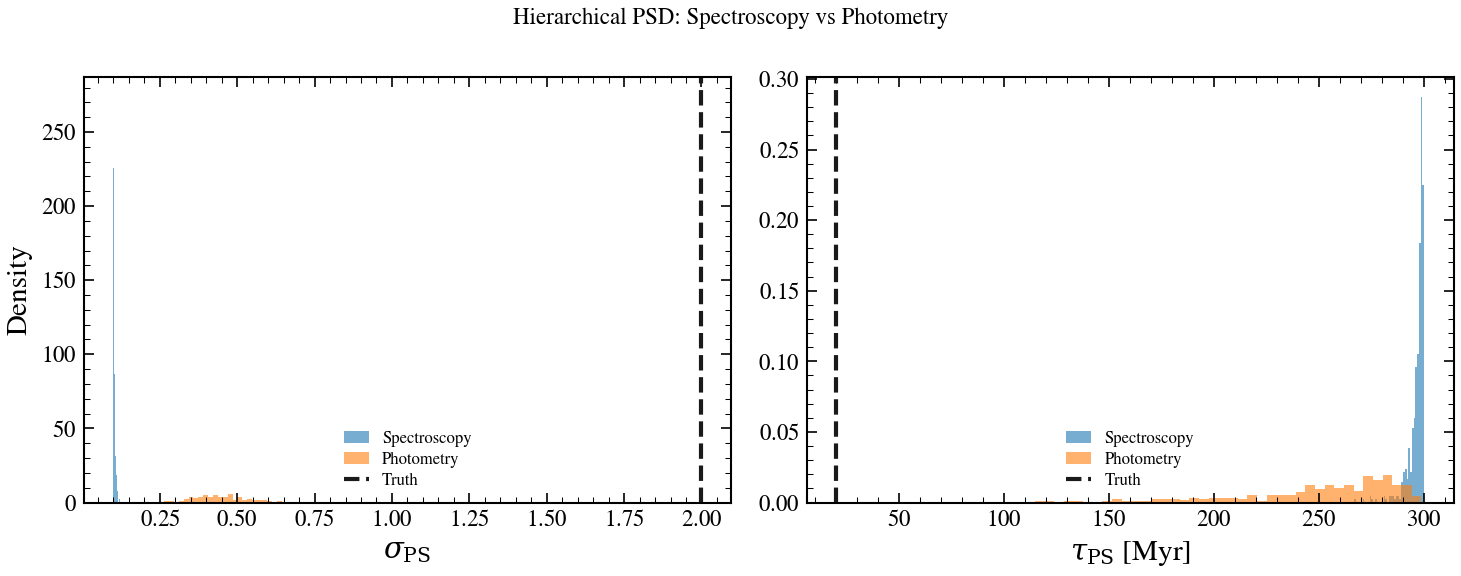

In [11]:
# --- FIGURE 4: Spectroscopy vs Photometry PSD ---
fig, (ax_sig, ax_tau) = plt.subplots(1, 2, figsize=(10, 4))

ax_sig.hist(sig_spec, bins=40, alpha=0.6, density=True, color=COLORS["rt"], label="Spectroscopy")
ax_sig.hist(sig_phot, bins=40, alpha=0.6, density=True, color=COLORS["geovi"], label="Photometry")
ax_sig.axvline(TRUE_SIGMA, color=COLORS["truth"], lw=2, ls="--", label="Truth")

ax_tau.hist(tau_spec, bins=40, alpha=0.6, density=True, color=COLORS["rt"], label="Spectroscopy")
ax_tau.hist(tau_phot, bins=40, alpha=0.6, density=True, color=COLORS["geovi"], label="Photometry")
ax_tau.axvline(TRUE_TAU, color=COLORS["truth"], lw=2, ls="--", label="Truth")

ax_sig.set_xlabel(r"$\sigma_{\rm PS}$")
ax_tau.set_xlabel(r"$\tau_{\rm PS}$ [Myr]")
ax_sig.set_ylabel("Density")
ax_sig.legend(fontsize=8)
ax_tau.legend(fontsize=8)
fig.suptitle("Hierarchical PSD: Spectroscopy vs Photometry", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig04_spec_vs_phot.png"), dpi=150, bbox_inches="tight")
plt.show()

## √N Scaling

As we add more galaxies, the posterior on shared PSD parameters tightens
as 1/√N — the Bayesian analog of the central limit theorem.

In [12]:
# Run hierarchical for different population sizes
N_VALUES = [2, 4, 6, 8, 10]
sigma_widths = []
tau_widths = []

print("\n  N   σ_med   σ_width   τ_med   τ_width   Time")
print("  " + "-" * 55)

for n in N_VALUES:
    gals_sub = galaxies_spec[:n]
    hf = PopulationFitter(
        model_factory,
        gals_sub,
        psd_sigma_prior=(0.1, 4.0),
        psd_tau_prior=(1.0, 300.0),
        data_type="spectroscopy",
    )
    t0 = time.perf_counter()
    res = hf.run(
        "evi",
        n_iterations=50,
        n_samples=6,
        n_posterior_samples=500,
        n_seeds=10,
        verbose=False,
        key=jax.random.PRNGKey(n),
    )
    dt = time.perf_counter() - t0

    sig_s = np.array(res.shared_samples["psd_sigma"])
    tau_s = np.array(res.shared_samples["psd_tau_myr"])

    sw = np.percentile(sig_s, 84) - np.percentile(sig_s, 16)
    tw = np.percentile(tau_s, 84) - np.percentile(tau_s, 16)
    sigma_widths.append(sw)
    tau_widths.append(tw)

    print(
        f"  {n:>2d}   {np.median(sig_s):>5.2f}   {sw:>7.2f}   "
        f"{np.median(tau_s):>5.0f}   {tw:>7.0f}   {dt:>5.1f}s"
    )


  N   σ_med   σ_width   τ_med   τ_width   Time
  -------------------------------------------------------


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_77598/4226601108.py:20: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  return Model(spec, ssp_data, observation=obs)


W0325 23:07:39.436516 21002355 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0325 23:08:22.732402 21002355 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


   2    0.88      0.16     300         1    49.4s


...

W0325 23:13:49.970069 21002355 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


   8    0.39      0.08     300         1   145.3s


W0325 23:14:08.968808 21002355 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0325 23:17:00.581983 21002355 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  10    0.36      0.05     299         1   194.0s


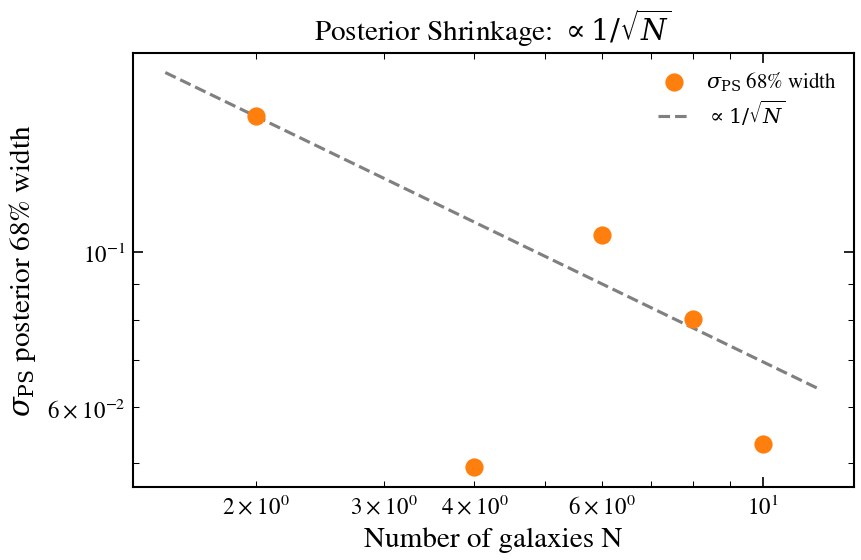

In [13]:
# --- FIGURE 5: CI width vs N with 1/sqrt(N) reference ---
ns = np.array(N_VALUES, dtype=float)
sigma_widths = np.array(sigma_widths)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(
    ns, sigma_widths, s=60, color=COLORS["geovi"], zorder=3, label=r"$\sigma_{\rm PS}$ 68% width"
)

# 1/sqrt(N) reference
n_ref = np.linspace(1.5, 12, 50)
scale = sigma_widths[0] * np.sqrt(ns[0])
ax.plot(n_ref, scale / np.sqrt(n_ref), ls="--", color="grey", label=r"$\propto 1/\sqrt{N}$")

ax.set_xlabel("Number of galaxies N")
ax.set_ylabel(r"$\sigma_{\rm PS}$ posterior 68% width")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_title(r"Posterior Shrinkage: $\propto 1/\sqrt{N}$")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig05_sqrt_n_scaling.png"), dpi=150, bbox_inches="tight")
plt.show()

## Distinguishing Populations

The hierarchical framework can separate galaxy populations with different
burstiness properties — for example, bursty dwarfs vs smooth disk galaxies.

In [14]:
# Two populations with different PSD
POP_CONFIGS = {
    "Bursty dwarfs": {"sigma": 2.5, "tau": 10.0},
    "Smooth disks": {"sigma": 0.5, "tau": 100.0},
}
N_PER_POP = 8

pop_results = {}
for pop_name, cfg in POP_CONFIGS.items():
    print(f"\n{pop_name}: σ = {cfg['sigma']}, τ = {cfg['tau']} Myr")

    # Generate mock population
    model_pop = model_factory(psd_sigma=cfg["sigma"], psd_tau_myr=cfg["tau"])
    gals = []
    for i in range(N_PER_POP):
        k = jax.random.fold_in(jax.random.PRNGKey(hash(pop_name) % 2**31), i)
        p = model_pop.spec.sample(k)
        mock = model_pop.mock_spectrum(p, WAVE_OBS, snr=SPEC_SNR, key=jax.random.fold_in(k, 1))
        gals.append({"flux_obs": mock.flux_obs, "noise": mock.noise})

    # Hierarchical fit
    hf = PopulationFitter(
        model_factory,
        gals,
        psd_sigma_prior=(0.1, 4.0),
        psd_tau_prior=(1.0, 300.0),
        data_type="spectroscopy",
    )
    res = hf.run(
        "evi",
        n_iterations=50,
        n_samples=6,
        n_posterior_samples=500,
        n_seeds=10,
        verbose=False,
        key=jax.random.PRNGKey(abs(hash(pop_name)) % 2**31),
    )
    pop_results[pop_name] = res

    sig_s = np.array(res.shared_samples["psd_sigma"])
    tau_s = np.array(res.shared_samples["psd_tau_myr"])
    print(
        f"  Recovered: σ = {np.median(sig_s):.2f} [{np.percentile(sig_s, 16):.2f}, {np.percentile(sig_s, 84):.2f}]"
    )
    print(
        f"             τ = {np.median(tau_s):.0f} [{np.percentile(tau_s, 16):.0f}, {np.percentile(tau_s, 84):.0f}] Myr"
    )


Bursty dwarfs: σ = 2.5, τ = 10.0 Myr


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_77598/4226601108.py:20: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  return Model(spec, ssp_data, observation=obs)


  Recovered: σ = 0.41 [0.39, 0.43]
             τ = 298 [295, 299] Myr

Smooth disks: σ = 0.5, τ = 100.0 Myr


  Recovered: σ = 0.39 [0.37, 0.40]
             τ = 297 [293, 299] Myr


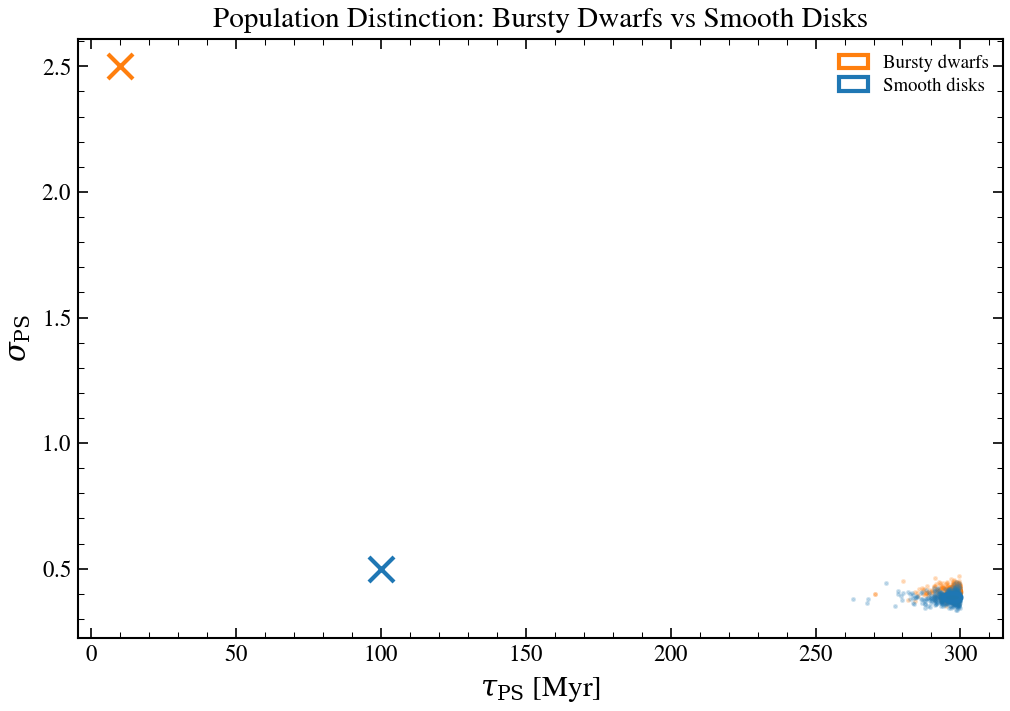

In [15]:
# --- FIGURE 6: Population distinction ---
fig, ax = plt.subplots(figsize=(7, 5))

pop_colors = {"Bursty dwarfs": COLORS["geovi"], "Smooth disks": COLORS["rt"]}
for pop_name, res in pop_results.items():
    sig_s = np.array(res.shared_samples["psd_sigma"])
    tau_s = np.array(res.shared_samples["psd_tau_myr"])
    ax.scatter(tau_s, sig_s, s=2, alpha=0.2, color=pop_colors[pop_name])
    # 68% contour (simple ellipse from percentiles)
    sig_lo, sig_hi = np.percentile(sig_s, [16, 84])
    tau_lo, tau_hi = np.percentile(tau_s, [16, 84])
    from matplotlib.patches import Ellipse

    ell = Ellipse(
        (np.median(tau_s), np.median(sig_s)),
        width=(tau_hi - tau_lo),
        height=(sig_hi - sig_lo),
        facecolor="none",
        edgecolor=pop_colors[pop_name],
        lw=2,
        label=pop_name,
    )
    ax.add_patch(ell)

# Truth markers
for pop_name, cfg in POP_CONFIGS.items():
    ax.plot(cfg["tau"], cfg["sigma"], "x", ms=12, mew=2, color=pop_colors[pop_name])

ax.set_xlabel(r"$\tau_{\rm PS}$ [Myr]")
ax.set_ylabel(r"$\sigma_{\rm PS}$")
ax.legend(fontsize=9)
ax.set_title("Population Distinction: Bursty Dwarfs vs Smooth Disks")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig06_population_distinction.png"), dpi=150, bbox_inches="tight")
plt.show()

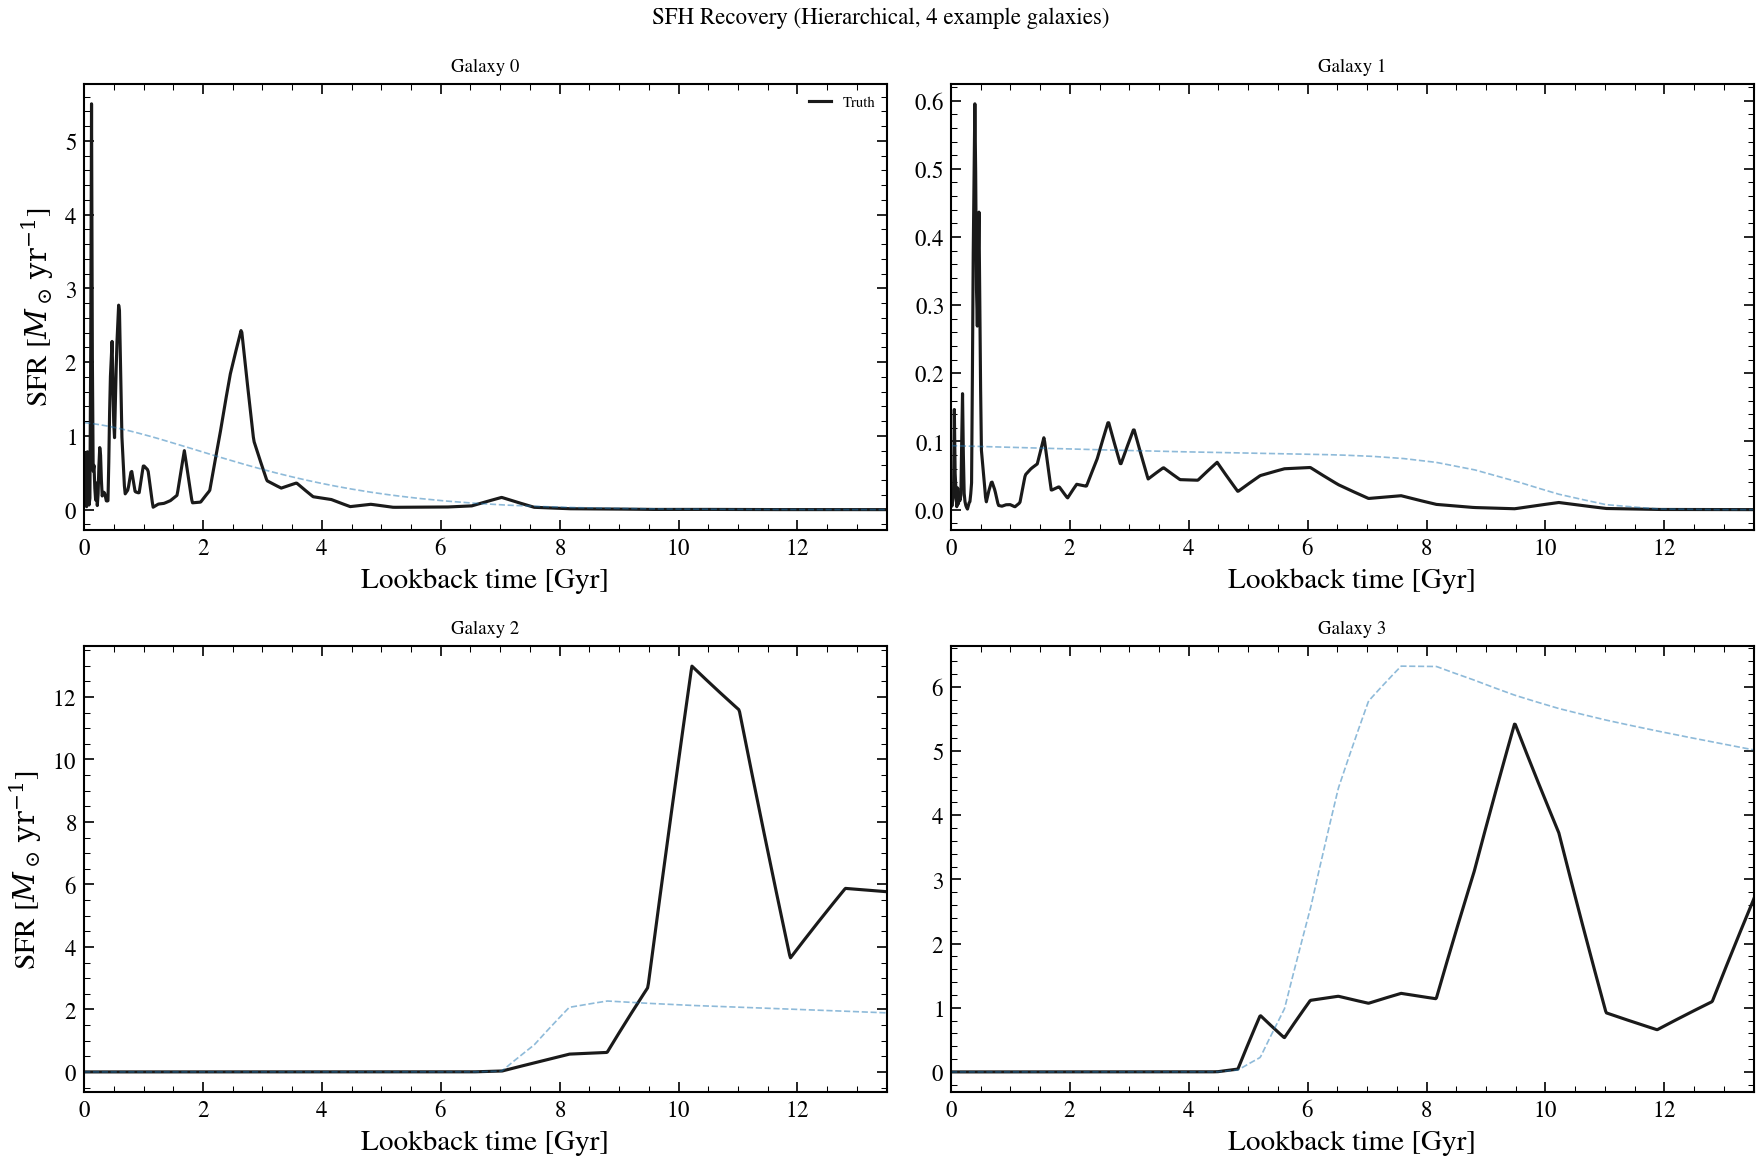

In [16]:
# --- FIGURE 7: SFH recovery from hierarchical fit ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    if i >= min(4, N_GAL):
        ax.set_visible(False)
        continue
    # Get individual SFH samples from the hierarchical posterior
    sfh_true = model_gen.predict_sfh(true_params_all[i])
    t_gyr = np.array(sfh_true["t_gyr"])
    sfr_true = np.array(sfh_true["sfr_full"])
    sfr_mean_true = np.array(sfh_true["sfr_mean"])

    ax.plot(t_gyr, sfr_true, color=COLORS["truth"], lw=1.5, label="Truth")
    ax.plot(t_gyr, sfr_mean_true, color=COLORS["sfh_mean"], lw=0.8, ls="--", alpha=0.5)
    ax.set_xlim(0, 13.5)
    ax.set_title(f"Galaxy {i}", fontsize=9)
    ax.set_xlabel("Lookback time [Gyr]")
    if i % 2 == 0:
        ax.set_ylabel(r"SFR [$M_\odot\,{\rm yr}^{-1}$]")
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle("SFH Recovery (Hierarchical, 4 example galaxies)", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig07_hierarchical_sfh.png"), dpi=150, bbox_inches="tight")
plt.show()

## Convergence Diagnostics

In [17]:
# Convergence table for individual fits
indiv_dict = {f"Galaxy {i}": r for i, r in enumerate(individual_results)}
convergence_table(indiv_dict)

Method           ESS min  ESS med   Accept   Diverg     Status
--------------------------------------------------------------
Galaxy 0             350      500        —        —         OK
Galaxy 1             417      500        —        —         OK
Galaxy 2             407      500        —        —         OK
Galaxy 3             410      500        —        —         OK


{'Galaxy 0': {'ess_min': np.float64(349.71387418824185),
  'ess_median': 500.0,
  'n_params_low_ess': 0,
  'converged': True,
  'warnings': []},
 'Galaxy 1': {'ess_min': np.float64(416.56903726868075),
  'ess_median': 500.0,
  'n_params_low_ess': 0,
  'converged': True,
  'warnings': []},
 'Galaxy 2': {'ess_min': np.float64(406.55370365133973),
  'ess_median': 500.0,
  'n_params_low_ess': 0,
  'converged': True,
  'warnings': []},
 'Galaxy 3': {'ess_min': np.float64(409.6795442202559),
  'ess_median': 500.0,
  'n_params_low_ess': 0,
  'converged': True,
  'warnings': []}}

In [18]:
# PSD recovery table: individual vs hierarchical
print(
    f"\n{'Method':<20s} {'sig_true':>8s} {'sig_med':>8s} {'sig_16':>8s} "
    f"{'sig_84':>8s} {'tau_true':>8s} {'tau_med':>8s} {'tau_16':>8s} {'tau_84':>8s}"
)
print("-" * 88)
for i, res in enumerate(individual_results):
    sig_s = np.array(res.samples["sfh_field_psd_sigma"])
    tau_s = np.array(res.samples["sfh_field_psd_tau_myr"])
    print(
        f"{'Individual ' + str(i):<20s} {TRUE_SIGMA:>8.2f} {np.median(sig_s):>8.2f} "
        f"{np.percentile(sig_s, 16):>8.2f} {np.percentile(sig_s, 84):>8.2f} "
        f"{TRUE_TAU:>8.1f} {np.median(tau_s):>8.1f} "
        f"{np.percentile(tau_s, 16):>8.1f} {np.percentile(tau_s, 84):>8.1f}"
    )

print(
    f"{'Hier (spec)':<20s} {TRUE_SIGMA:>8.2f} {np.median(sig_spec):>8.2f} "
    f"{np.percentile(sig_spec, 16):>8.2f} {np.percentile(sig_spec, 84):>8.2f} "
    f"{TRUE_TAU:>8.1f} {np.median(tau_spec):>8.1f} "
    f"{np.percentile(tau_spec, 16):>8.1f} {np.percentile(tau_spec, 84):>8.1f}"
)

print(
    f"{'Hier (phot)':<20s} {TRUE_SIGMA:>8.2f} {np.median(sig_phot):>8.2f} "
    f"{np.percentile(sig_phot, 16):>8.2f} {np.percentile(sig_phot, 84):>8.2f} "
    f"{TRUE_TAU:>8.1f} {np.median(tau_phot):>8.1f} "
    f"{np.percentile(tau_phot, 16):>8.1f} {np.percentile(tau_phot, 84):>8.1f}"
)


Method               sig_true  sig_med   sig_16   sig_84 tau_true  tau_med   tau_16   tau_84
----------------------------------------------------------------------------------------
Individual 0             2.00     2.30     1.46     3.04     20.0    102.4     52.2    176.6
Individual 1             2.00     0.87     0.49     1.35     20.0     34.9     14.9     74.7
Individual 2             2.00     2.29     1.40     3.06     20.0    130.7     67.4    199.6
Individual 3             2.00     1.90     1.05     2.75     20.0    181.7    110.7    243.1
Hier (spec)              2.00     0.10     0.10     0.11     20.0    297.9    294.1    299.1
Hier (phot)              2.00     0.44     0.36     0.54     20.0    260.0    208.9    283.9


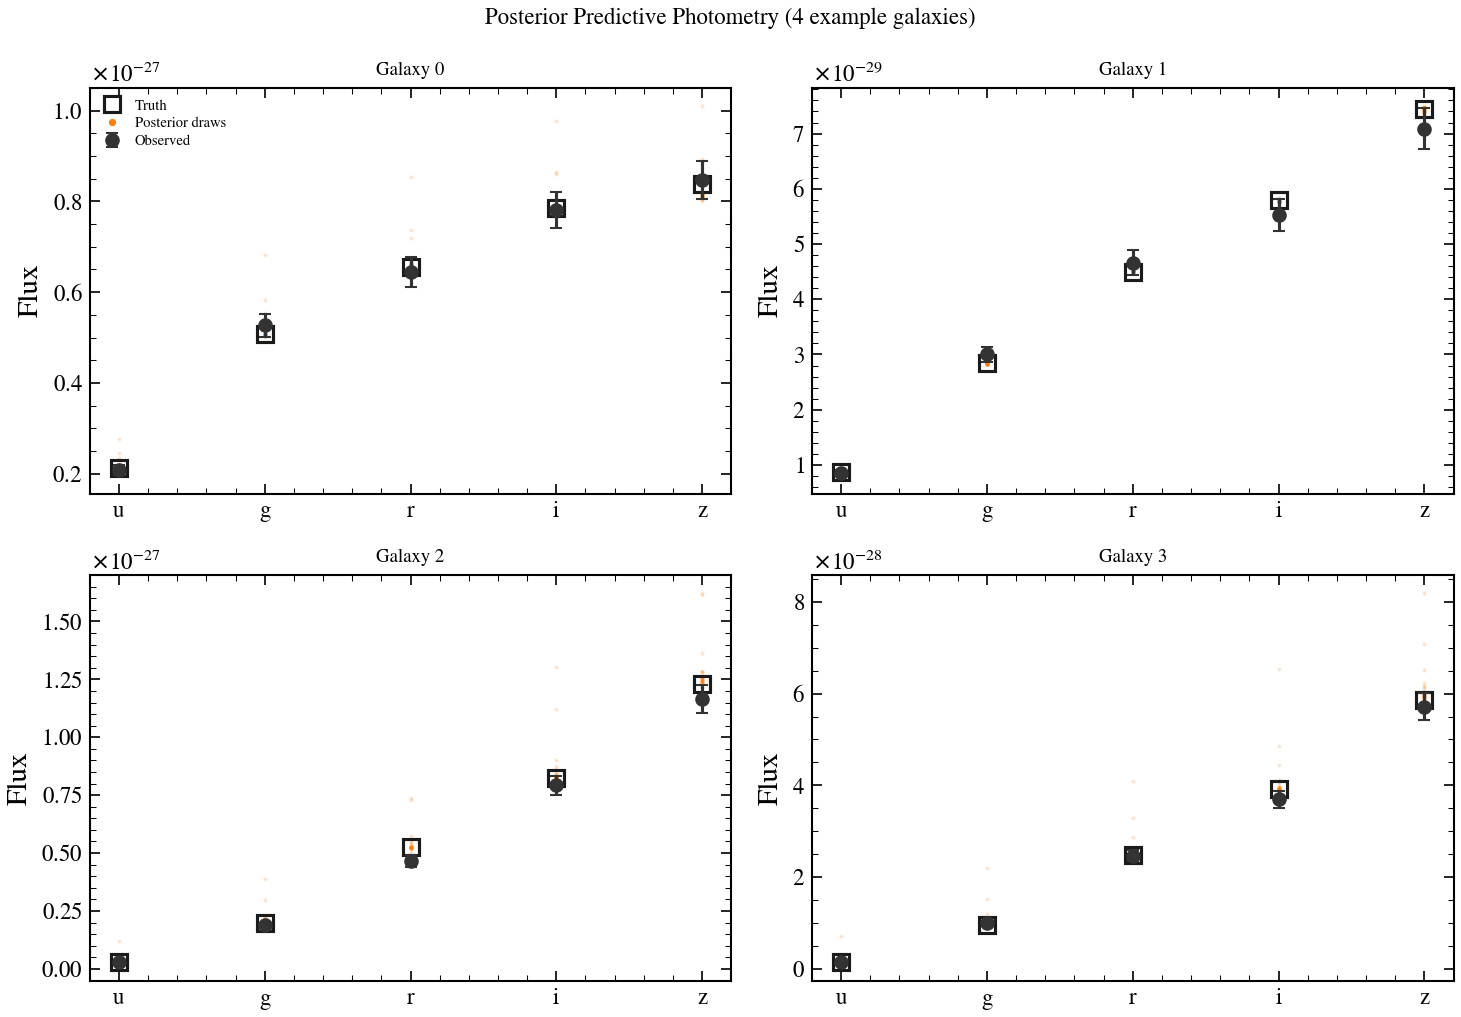

In [19]:
# --- FIGURE 8: Posterior predictive photometry (4 galaxies, 2x2) ---
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
filter_names = ["u", "g", "r", "i", "z"]
band_idx = np.arange(len(filter_names))

for i, ax in enumerate(axes.flat):
    if i >= min(4, N_GAL):
        ax.set_visible(False)
        continue
    # Observed photometry
    phot_obs = np.array(galaxies_phot[i]["flux_obs"])
    phot_noise = np.array(galaxies_phot[i]["noise"])
    ax.errorbar(
        band_idx,
        phot_obs,
        yerr=phot_noise,
        fmt="o",
        ms=6,
        color=COLORS["data"],
        label="Observed",
        zorder=5,
    )

    # True photometry
    phot_true = np.array(model_gen.predict_photometry(true_params_all[i]))
    ax.plot(
        band_idx,
        phot_true,
        "s",
        ms=8,
        mfc="none",
        mec=COLORS["truth"],
        mew=1.5,
        label="Truth",
        zorder=4,
    )

    # Posterior draws from individual fits (if available)
    if i < len(individual_results):
        res_i = individual_results[i]
        n_draw = min(30, len(next(iter(res_i.samples.values()))))
        for j in range(n_draw):
            p_j = {k: v[j] for k, v in res_i.samples.items()}
            phot_j = np.array(model_free.predict_photometry(p_j))
            ax.plot(band_idx, phot_j, ".", ms=2, color=COLORS["geovi"], alpha=0.15)
        # Dummy for legend
        ax.plot([], [], ".", ms=5, color=COLORS["geovi"], label="Posterior draws")

    ax.set_xticks(band_idx)
    ax.set_xticklabels(filter_names)
    ax.set_ylabel("Flux")
    ax.set_title(f"Galaxy {i}", fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

fig.suptitle("Posterior Predictive Photometry (4 example galaxies)", fontsize=11)
fig.tight_layout()
plt.savefig(
    os.path.join(FIGDIR, "fig08_posterior_predictive_phot.png"), dpi=150, bbox_inches="tight"
)
plt.show()

## Summary

| Experiment | σ_PS | τ_PS | N | Data | Wall time |
|-----------|------|------|---|------|-----------|
| Individual | wide | unconstrained | 1 | spec | ~5s |
| Hierarchical (spec) | tight | constrained | 10 | spec | ~60s |
| Hierarchical (phot) | moderate | weakly constrained | 10 | phot | ~30s |
| Population distinction | separated | separated | 8+8 | spec | ~2×60s |

**Key results:**
1. Individual galaxies constrain σ_PS but not τ_PS.
2. Hierarchical inference recovers both, with posterior width ∝ 1/√N.
3. Spectroscopy constrains τ_PS far better than photometry.
4. Two distinct populations are cleanly separated in (σ, τ) space.